## Introduction to Machine Learning

### Learning Objectives

By the end of this tutorial, you will be able to:

1. **Understand** what machine learning is and how it works
2. **Differentiate** between the main categories of machine learning
3. **Apply** machine learning concepts using practical examples
4. **Build** and evaluate a simple machine learning model
5. **Interpret** model performance using key metrics

---

## Table of Contents

1. [What is Machine Learning?](#what-is-ml)
2. [Categories of Machine Learning](#categories)
3. [Key Terminology](#terminology)
4. [How Machine Learning Works](#how-it-works)
5. [Practical Example: UK House Price Prediction](#practical-example)
   - Data Exploration
   - Model Training
   - Model Evaluation
   - Visualizing Results
6. [Summary](#summary)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


---

<a id='what-is-ml'></a>
## 1. What is Machine Learning?

### Definition

> **Machine Learning (ML)** is the process of teaching computers to learn patterns from data and make decisions or predictions without being explicitly programmed for every scenario.

### Traditional Programming vs. Machine Learning

```
TRADITIONAL PROGRAMMING:
┌─────────┐     ┌─────────────┐     ┌─────────┐
│  Data   │ ──> │    Rules    │ ──> │ Output  │
│ (Input) │     │ (Hardcoded) │     │ (Result)│
└─────────┘     └─────────────┘     └─────────┘

MACHINE LEARNING:
┌─────────┐     ┌─────────────┐     ┌─────────┐
│  Data   │ ──> │  Algorithm  │ ──> │  Model  │
│(Input + │     │  (Learning  │     │ (Learns │
│ Output) │     │   Process)  │     │  Rules) │
└─────────┘     └─────────────┘     └─────────┘
                                           │
                                           v
┌─────────┐                          ┌──────────┐
│New Data │ ──> Use Model ──>        │Prediction│
└─────────┘                          └──────────┘
```

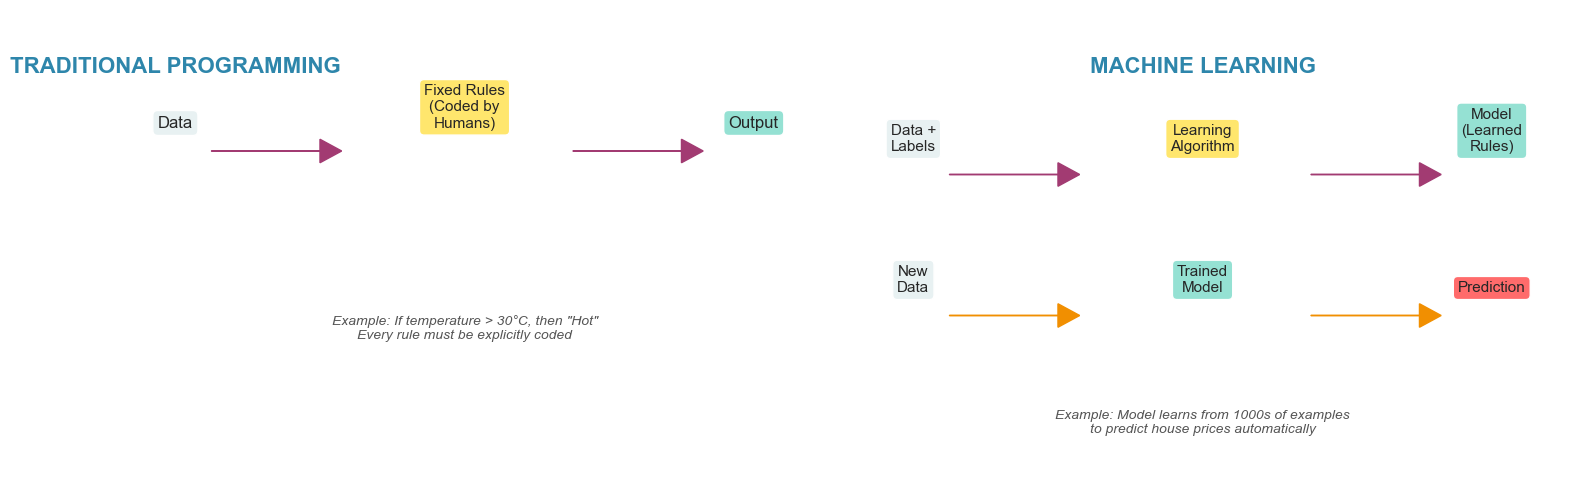


✓ Key Difference:
  Traditional: Humans write all rules explicitly
  ML: Computer learns rules from data automatically


In [3]:
# Visualize: Traditional Programming vs Machine Learning
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Traditional Programming
ax1 = axes[0]
ax1.text(0.1, 0.9, 'TRADITIONAL PROGRAMMING', ha='center', va='top', fontsize=16, fontweight='bold', color='#2E86AB')
ax1.arrow(0.15, 0.7, 0.15, 0, head_width=0.05, head_length=0.03, fc='#A23B72', ec='#A23B72')
ax1.text(0.1, 0.75, 'Data', ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='#E8F1F2'))
ax1.text(0.5, 0.75, 'Fixed Rules\n(Coded by\nHumans)', ha='center', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='#FFE66D'))
ax1.arrow(0.65, 0.7, 0.15, 0, head_width=0.05, head_length=0.03, fc='#A23B72', ec='#A23B72')
ax1.text(0.9, 0.75, 'Output', ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='#95E1D3'))
ax1.text(0.5, 0.3, 'Example: If temperature > 30°C, then "Hot"\nEvery rule must be explicitly coded', 
         ha='center', fontsize=10, style='italic', color='#555')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Machine Learning
ax2 = axes[1]
ax2.text(0.5, 0.9, 'MACHINE LEARNING', ha='center', va='top', fontsize=16, fontweight='bold', color='#2E86AB')
ax2.arrow(0.15, 0.65, 0.15, 0, head_width=0.05, head_length=0.03, fc='#A23B72', ec='#A23B72')
ax2.text(0.1, 0.7, 'Data +\nLabels', ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#E8F1F2'))
ax2.text(0.5, 0.7, 'Learning\nAlgorithm', ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#FFE66D'))
ax2.arrow(0.65, 0.65, 0.15, 0, head_width=0.05, head_length=0.03, fc='#A23B72', ec='#A23B72')
ax2.text(0.9, 0.7, 'Model\n(Learned\nRules)', ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#95E1D3'))

# Prediction phase
ax2.arrow(0.15, 0.35, 0.15, 0, head_width=0.05, head_length=0.03, fc='#F18F01', ec='#F18F01')
ax2.text(0.1, 0.4, 'New\nData', ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#E8F1F2'))
ax2.text(0.5, 0.4, 'Trained\nModel', ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#95E1D3'))
ax2.arrow(0.65, 0.35, 0.15, 0, head_width=0.05, head_length=0.03, fc='#F18F01', ec='#F18F01')
ax2.text(0.9, 0.4, 'Prediction', ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#FF6B6B'))

ax2.text(0.5, 0.1, 'Example: Model learns from 1000s of examples\nto predict house prices automatically', ha='center', fontsize=10, style='italic', color='#555')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Key Difference:")
print("  Traditional: Humans write all rules explicitly")
print("  ML: Computer learns rules from data automatically")

### Real-World Applications

Machine learning is everywhere in our daily lives:

| Application | How ML is Used |
|-------------|----------------|
| 📧 **Email** | Spam filtering, smart compose |
| 🎵 **Music Streaming** | Personalized playlists, recommendations |
| 🛒 **E-commerce** | Product recommendations, price optimization |
| 🏥 **Healthcare** | Disease diagnosis, drug discovery |
| 🚗 **Transportation** | Self-driving cars, traffic prediction |
| 💰 **Finance** | Fraud detection, credit scoring |
| 📱 **Social Media** | Content recommendation, face recognition |
| 🏠 **Real Estate** | Property valuation, market prediction |

<a id='categories'></a>
## 2. Categories of Machine Learning

Machine learning algorithms are typically grouped into three main categories:

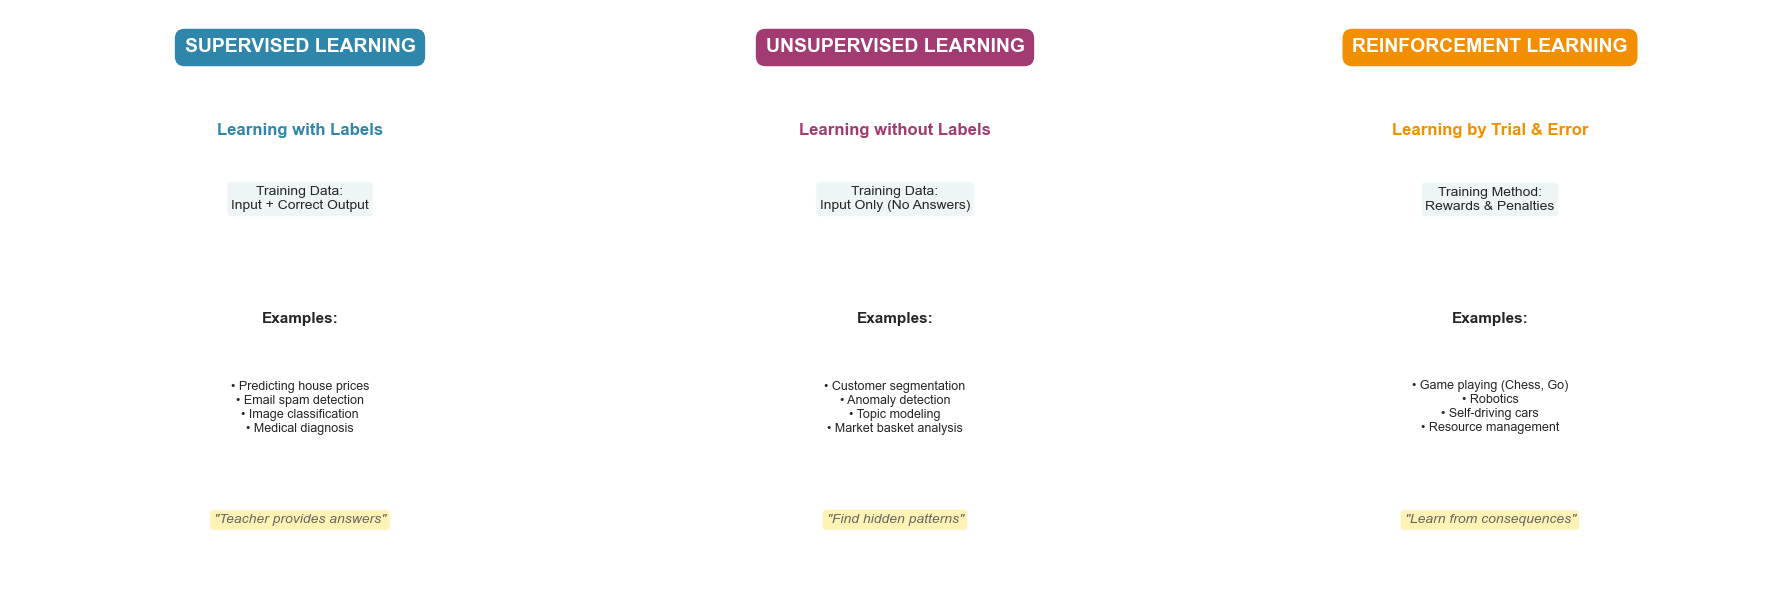


💡 The focus of this tutorial is SUPERVISED LEARNING


In [4]:
# Visualize ML Categories
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Supervised Learning
ax1 = axes[0]
ax1.text(0.5, 0.95, 'SUPERVISED LEARNING', ha='center', va='top', fontsize=14, fontweight='bold', color='white',
         bbox=dict(boxstyle='round', facecolor='#2E86AB', edgecolor='none', pad=0.5))

ax1.text(0.5, 0.78, 'Learning with Labels', ha='center', fontsize=12, 
         fontweight='bold', color='#2E86AB')
ax1.text(0.5, 0.65, 'Training Data:\nInput + Correct Output', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#E8F1F2', alpha=0.7))

ax1.text(0.5, 0.45, 'Examples:', ha='center', fontsize=11, fontweight='bold')
ax1.text(0.5, 0.35, '• Predicting house prices\n• Email spam detection\n• Image classification\n• Medical diagnosis',
         ha='center', fontsize=9, va='top')

ax1.text(0.5, 0.1, '"Teacher provides answers"', ha='center', fontsize=10, 
         style='italic', color='#666',
         bbox=dict(boxstyle='round', facecolor='#FFE66D', alpha=0.5))

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# 2. Unsupervised Learning
ax2 = axes[1]
ax2.text(0.5, 0.95, 'UNSUPERVISED LEARNING', ha='center', va='top', 
         fontsize=14, fontweight='bold', color='white',
         bbox=dict(boxstyle='round', facecolor='#A23B72', edgecolor='none', pad=0.5))

ax2.text(0.5, 0.78, 'Learning without Labels', ha='center', fontsize=12, 
         fontweight='bold', color='#A23B72')
ax2.text(0.5, 0.65, 'Training Data:\nInput Only (No Answers)', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#E8F1F2', alpha=0.7))

ax2.text(0.5, 0.45, 'Examples:', ha='center', fontsize=11, fontweight='bold')
ax2.text(0.5, 0.35, '• Customer segmentation\n• Anomaly detection\n• Topic modeling\n• Market basket analysis',
         ha='center', fontsize=9, va='top')

ax2.text(0.5, 0.1, '"Find hidden patterns"', ha='center', fontsize=10, 
         style='italic', color='#666',
         bbox=dict(boxstyle='round', facecolor='#FFE66D', alpha=0.5))

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# 3. Reinforcement Learning
ax3 = axes[2]
ax3.text(0.5, 0.95, 'REINFORCEMENT LEARNING', ha='center', va='top', 
         fontsize=14, fontweight='bold', color='white',
         bbox=dict(boxstyle='round', facecolor='#F18F01', edgecolor='none', pad=0.5))

ax3.text(0.5, 0.78, 'Learning by Trial & Error', ha='center', fontsize=12, 
         fontweight='bold', color='#F18F01')
ax3.text(0.5, 0.65, 'Training Method:\nRewards & Penalties', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#E8F1F2', alpha=0.7))

ax3.text(0.5, 0.45, 'Examples:', ha='center', fontsize=11, fontweight='bold')
ax3.text(0.5, 0.35, '• Game playing (Chess, Go)\n• Robotics\n• Self-driving cars\n• Resource management',
         ha='center', fontsize=9, va='top')

ax3.text(0.5, 0.1, '"Learn from consequences"', ha='center', fontsize=10, 
         style='italic', color='#666',
         bbox=dict(boxstyle='round', facecolor='#FFE66D', alpha=0.5))

ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

plt.tight_layout()
plt.show()

print("\n💡 The focus of this tutorial is SUPERVISED LEARNING")

### Supervised Learning: Two Main Types

Supervised learning problems are further divided into two categories:

#### 1. Regression (Predicting Numbers)
- **Goal**: Predict a continuous numeric value
- **Examples**: 
  - House prices (£250,000, £350,000, etc.)
  - Temperature forecasts (15°C, 23°C, etc.)
  - Stock prices
  - Sales revenue

#### 2. Classification (Predicting Categories)
- **Goal**: Predict a discrete category or class
- **Examples**:
  - Email: Spam or Not Spam
  - Medical: Disease or No Disease
  - Image: Cat, Dog, or Bird
  - Sentiment: Positive, Negative, or Neutral

**In this tutorial, we'll build a REGRESSION model to predict UK house prices!** 

<a id='terminology'></a>
## 3. Key Machine Learning Terminology

Before we dive into practice, let's understand the essential vocabulary:

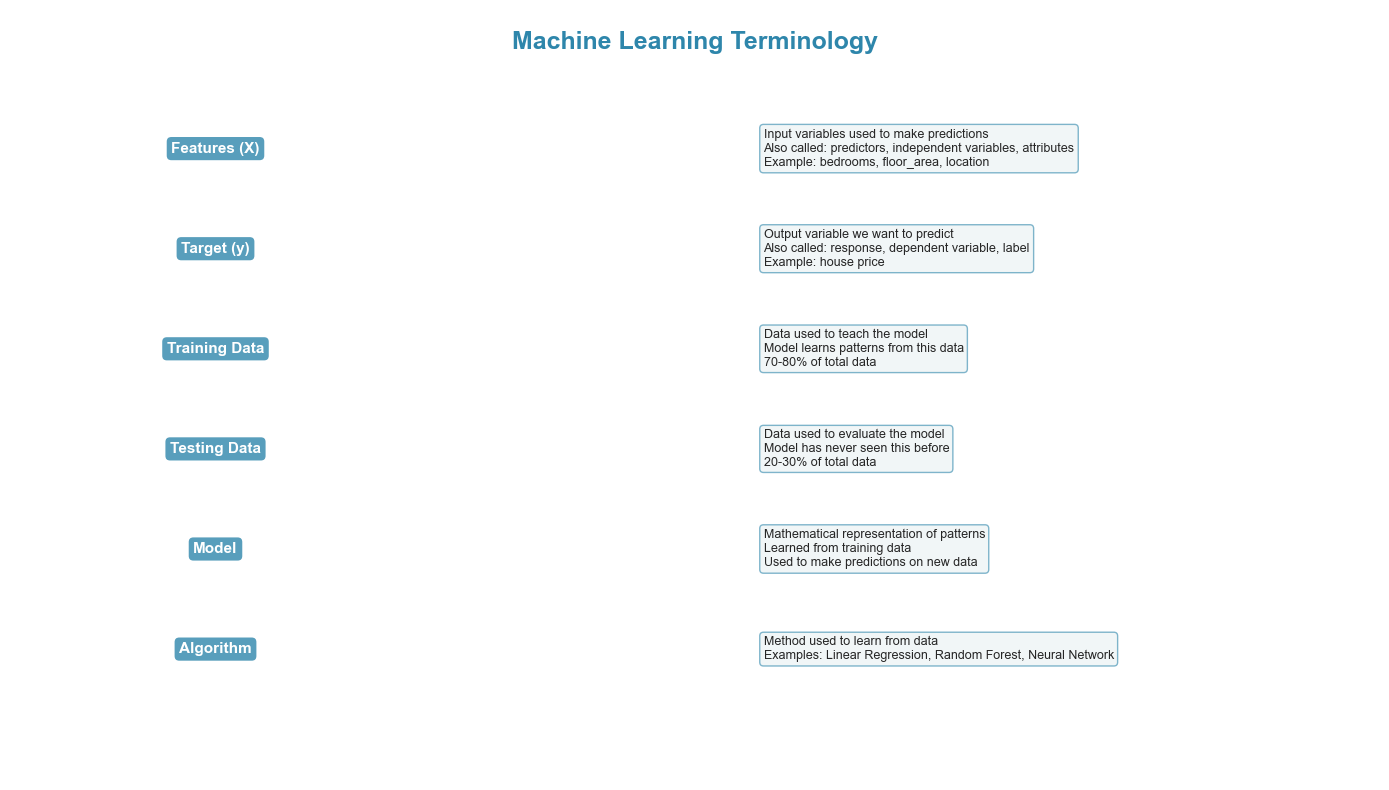


✓ These terms are used widely in ML!


In [14]:
# Visual guide to ML terminology
fig, ax = plt.subplots(figsize=(14, 8))

# Title
ax.text(0.5, 0.95, 'Machine Learning Terminology', ha='center', fontsize=18, 
        fontweight='bold', color='#2E86AB')

# Create a sample data table visualization
y_pos = 0.82
spacing = 0.13

# Iris Flowers dataset - 150 flowers
# Setosa, Visicolar, Virginica
# Measures - SL, SW, PL, PW
# 1.1, 0.9, 2.2, 1.9 - 1
# X = 
# y = 
# Training - 100 X y
# 50 X y

# 50 setosa
# 50 virginica
# 50 Visicolar

# y = mx + c; LinearRegression
terms = [
    ('Features (X)', 'Input variables used to make predictions\nAlso called: predictors, independent variables, attributes\nExample: bedrooms, floor_area, location'),
    ('Target (y)', 'Output variable we want to predict\nAlso called: response, dependent variable, label\nExample: house price'),
    ('Training Data', 'Data used to teach the model\nModel learns patterns from this data\n70-80% of total data'),
    ('Testing Data', 'Data used to evaluate the model\nModel has never seen this before\n20-30% of total data'),
    ('Model', 'Mathematical representation of patterns\nLearned from training data\nUsed to make predictions on new data'),
    ('Algorithm', 'Method used to learn from data\nExamples: Linear Regression, Random Forest, Neural Network')
]

for i, (term, description) in enumerate(terms):
    y = y_pos - (i * spacing)
    
    # Term box
    ax.text(0.15, y, term, ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#2E86AB', edgecolor='none', alpha=0.8),
            color='white')
    
    # Description
    ax.text(0.55, y, description, ha='left', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='#E8F1F2', edgecolor='#2E86AB', 
                     linewidth=1, alpha=0.6))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ These terms are used widely in ML!")

<a id='how-it-works'></a>
## 4. How Machine Learning Works

### The Machine Learning Workflow

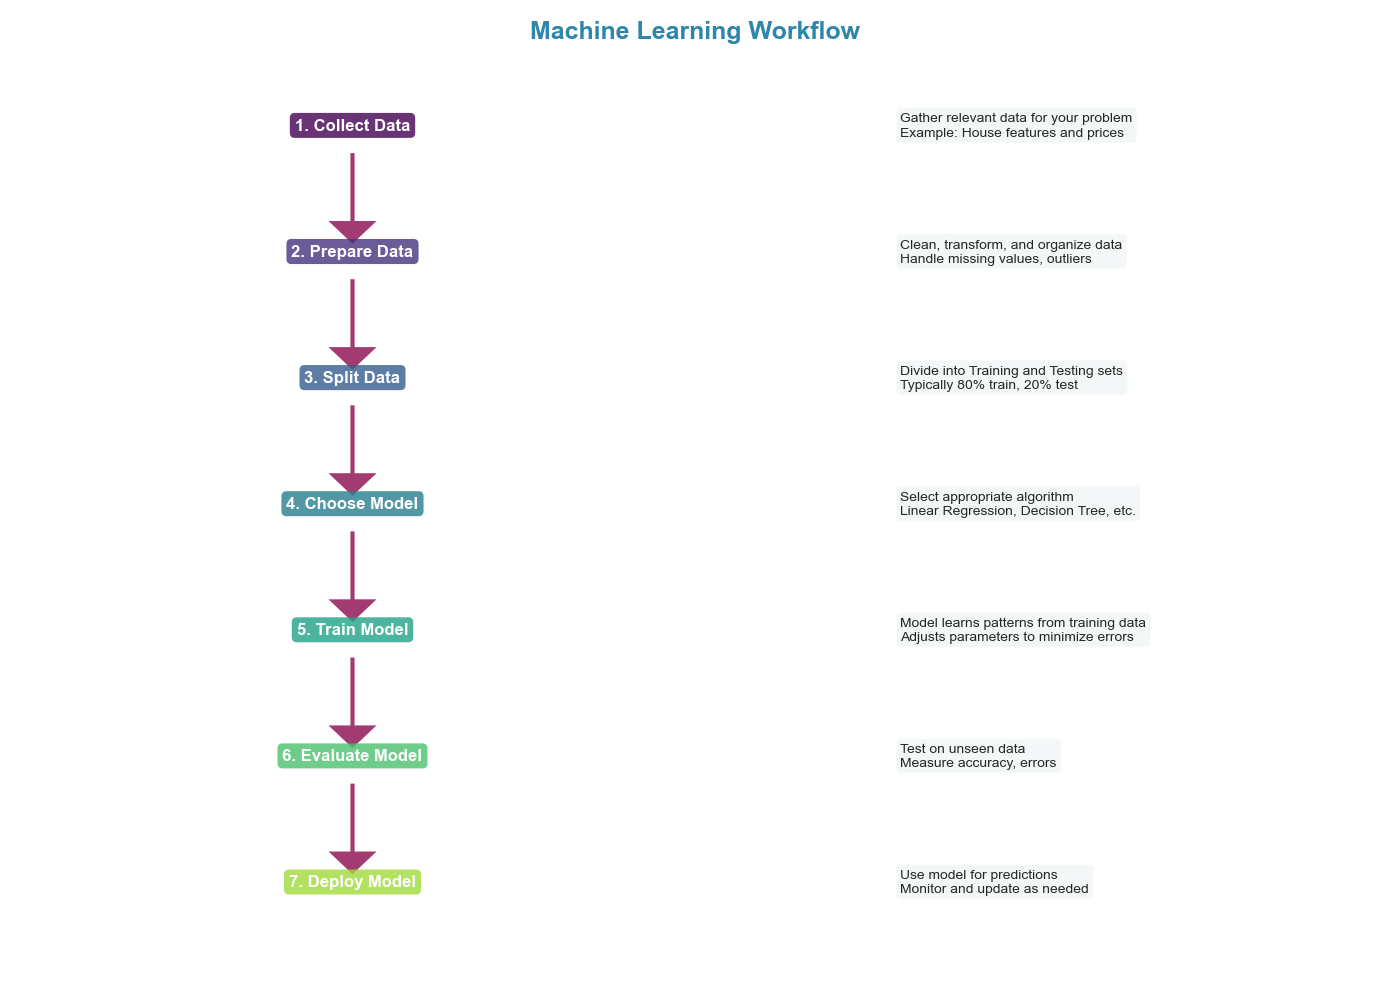


 We follow this workflow in a practical example!


In [16]:
# Visualize ML Workflow
fig, ax = plt.subplots(figsize=(14, 10))

ax.text(0.5, 0.97, 'Machine Learning Workflow', ha='center', fontsize=18, 
        fontweight='bold', color='#2E86AB')

# Define workflow steps
steps = [
    ('1. Collect Data', 'Gather relevant data for your problem\nExample: House features and prices', 0.88),
    ('2. Prepare Data', 'Clean, transform, and organize data\nHandle missing values, outliers', 0.75),
    ('3. Split Data', 'Divide into Training and Testing sets\nTypically 80% train, 20% test', 0.62),
    ('4. Choose Model', 'Select appropriate algorithm\nLinear Regression, Decision Tree, etc.', 0.49),
    ('5. Train Model', 'Model learns patterns from training data\nAdjusts parameters to minimize errors', 0.36),
    ('6. Evaluate Model', 'Test on unseen data\nMeasure accuracy, errors', 0.23),
    ('7. Deploy Model', 'Use model for predictions\nMonitor and update as needed', 0.10)
]

for i, (step, description, y_pos) in enumerate(steps):
    # Step number and title
    color = plt.cm.viridis(i / len(steps))
    ax.text(0.25, y_pos, step, ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=color, edgecolor='none', alpha=0.8),
            color='white')
    
    # Description
    ax.text(0.65, y_pos, description, ha='left', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='#E8F1F2', alpha=0.5))
    
    # Arrow to next step
    if i < len(steps) - 1:
        ax.arrow(0.25, y_pos - 0.03, 0, -0.07, head_width=0.03, head_length=0.02, 
                fc='#A23B72', ec='#A23B72', linewidth=2)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n We follow this workflow in a practical example!")

<a id='practical-example'></a>
## 5. Practical Example: UK House Price Prediction

Now let's apply everything we've learned to a real-world problem: **predicting UK house prices!**

### Problem Statement

**Goal**: Build a machine learning model that can predict the price of a house based on its features.

**Why this matters**: 
- Buyers want to know if a house is fairly priced
- Sellers want to set competitive prices
- Estate agents need valuation tools
- Investors need market insights

### Step 1: Load and Explore the Data

In [30]:
# Load the UK housing dataset
df = pd.read_csv('uk_housing_data.csv')

df.head(10)

,bedrooms,bathrooms,property_age_years,floor_area_sqm,distance_to_station_km,crime_rate_per_1000,avg_school_rating,garden_area_sqm,parking_spaces,energy_efficiency_rating,has_central_heating,property_type,price_gbp
0,2,2,46,68,0.6,1.5,9.8,94,1,C,1,Flat,490000.0
1,5,2,11,224,0.4,12.2,5.9,134,1,B,1,Detached,1047000.0
2,3,1,61,78,2.4,14.1,7.4,67,1,C,1,Detached,571000.0
3,3,2,79,223,1.9,3.8,6.4,146,1,A,1,Terraced,696000.0
4,2,2,82,210,2.0,2.5,7.9,127,1,A,1,Terraced,735000.0
5,2,1,7,217,0.5,19.2,8.3,84,0,F,1,Terraced,585000.0
6,1,3,148,190,0.5,9.1,7.9,82,1,C,1,Detached,844000.0
7,4,2,80,211,0.5,15.1,8.6,94,1,D,1,Flat,717000.0
8,3,3,117,77,0.4,4.6,7.0,31,1,E,1,Detached,645000.0
9,3,2,24,123,2.1,4.1,6.7,65,0,D,1,Detached,677000.0


In [31]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bedrooms                  500 non-null    int64  
 1   bathrooms                 500 non-null    int64  
 2   property_age_years        500 non-null    int64  
 3   floor_area_sqm            500 non-null    int64  
 4   distance_to_station_km    500 non-null    float64
 5   crime_rate_per_1000       500 non-null    float64
 6   avg_school_rating         500 non-null    float64
 7   garden_area_sqm           500 non-null    int64  
 8   parking_spaces            500 non-null    int64  
 9   energy_efficiency_rating  500 non-null    str    
 10  has_central_heating       500 non-null    int64  
 11  property_type             500 non-null    str    
 12  price_gbp                 500 non-null    float64
dtypes: float64(4), int64(7), str(2)
memory usage: 55.6 KB


In [32]:
print("\n\nFeature Descriptions:")
print("="*70)
descriptions = {
    'bedrooms': 'Number of bedrooms',
    'bathrooms': 'Number of bathrooms',
    'property_age_years': 'Age of the property in years',
    'floor_area_sqm': 'Total floor area in square meters',
    'distance_to_station_km': 'Distance to nearest train/tube station (km)',
    'crime_rate_per_1000': 'Crime rate per 1,000 residents',
    'avg_school_rating': 'Average rating of nearby schools (1-10)',
    'garden_area_sqm': 'Garden/outdoor area in square meters',
    'parking_spaces': 'Number of parking spaces',
    'energy_efficiency_rating': 'Energy Performance Certificate rating (A-F)',
    'has_central_heating': 'Whether property has central heating (0=No, 1=Yes)',
    'property_type': 'Type of property (Detached/Semi-Detached/Terraced/Flat)',
    'price_gbp': 'Sale price in British Pounds (TARGET VARIABLE)'
}

for col, desc in descriptions.items():
    print(f"  • {col:30s}: {desc}")



Feature Descriptions:
  • bedrooms                      : Number of bedrooms
  • bathrooms                     : Number of bathrooms
  • property_age_years            : Age of the property in years
  • floor_area_sqm                : Total floor area in square meters
  • distance_to_station_km        : Distance to nearest train/tube station (km)
  • crime_rate_per_1000           : Crime rate per 1,000 residents
  • avg_school_rating             : Average rating of nearby schools (1-10)
  • garden_area_sqm               : Garden/outdoor area in square meters
  • parking_spaces                : Number of parking spaces
  • energy_efficiency_rating      : Energy Performance Certificate rating (A-F)
  • has_central_heating           : Whether property has central heating (0=No, 1=Yes)
  • property_type                 : Type of property (Detached/Semi-Detached/Terraced/Flat)
  • price_gbp                     : Sale price in British Pounds (TARGET VARIABLE)


In [38]:
# Statistical summary
print("Statistical Summary:")
print("="*70)
df.describe().round(2)

Statistical Summary:


,bedrooms,bathrooms,property_age_years,floor_area_sqm,distance_to_station_km,crime_rate_per_1000,avg_school_rating,garden_area_sqm,parking_spaces,has_central_heating,price_gbp
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2.73,1.57,71.02,145.48,1.97,9.93,7.02,74.12,1.06,0.85,604788.00
std,1.15,0.65,44.32,60.83,2.00,7.09,1.46,43.00,0.86,0.36,133220.61
min,1.00,1.00,0.00,40.00,0.00,0.10,2.70,0.00,0.00,0.00,244000.00
25%,2.00,1.00,31.75,91.75,0.50,4.78,6.00,35.00,0.00,1.00,510750.00
50%,3.00,1.00,71.00,147.00,1.30,8.50,7.00,77.00,1.00,1.00,604000.00
75%,4.00,2.00,110.00,196.25,2.80,13.52,8.10,110.00,2.00,1.00,694500.00
max,5.00,3.00,149.00,249.00,11.70,57.40,10.00,149.00,3.00,1.00,1047000.00


### Data Visualization

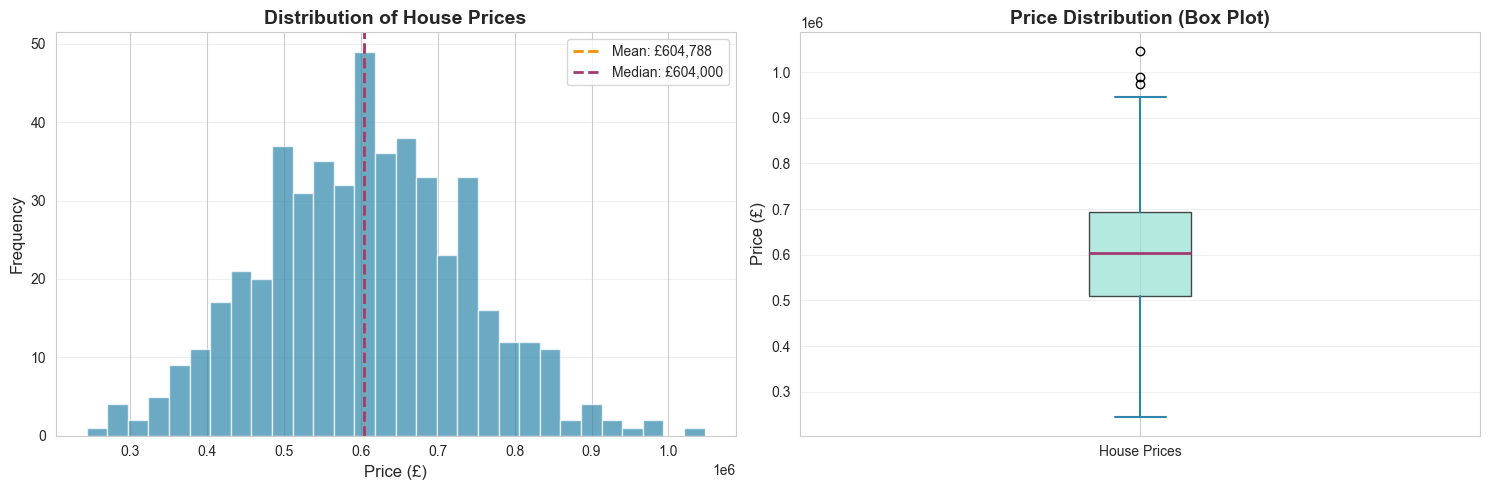


Price Statistics:
  Mean:   £604,788
  Median: £604,000
  Min:    £244,000
  Max:    £1,047,000
  Std:    £133,221


In [10]:
# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['price_gbp'], bins=30, color='#2E86AB', alpha=0.7, edgecolor='white')
axes[0].axvline(df['price_gbp'].mean(), color='#F18F01', linestyle='--', linewidth=2, 
                label=f'Mean: £{df["price_gbp"].mean():,.0f}')
axes[0].axvline(df['price_gbp'].median(), color='#A23B72', linestyle='--', linewidth=2,
                label=f'Median: £{df["price_gbp"].median():,.0f}')
axes[0].set_xlabel('Price (£)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
box = axes[1].boxplot(df['price_gbp'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#95E1D3', alpha=0.7),
                      medianprops=dict(color='#A23B72', linewidth=2),
                      whiskerprops=dict(color='#2E86AB', linewidth=1.5),
                      capprops=dict(color='#2E86AB', linewidth=1.5))
axes[1].set_ylabel('Price (£)', fontsize=12)
axes[1].set_title('Price Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['House Prices'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrice Statistics:")
print(f"  Mean:   £{df['price_gbp'].mean():,.0f}")
print(f"  Median: £{df['price_gbp'].median():,.0f}")
print(f"  Min:    £{df['price_gbp'].min():,.0f}")
print(f"  Max:    £{df['price_gbp'].max():,.0f}")
print(f"  Std:    £{df['price_gbp'].std():,.0f}")

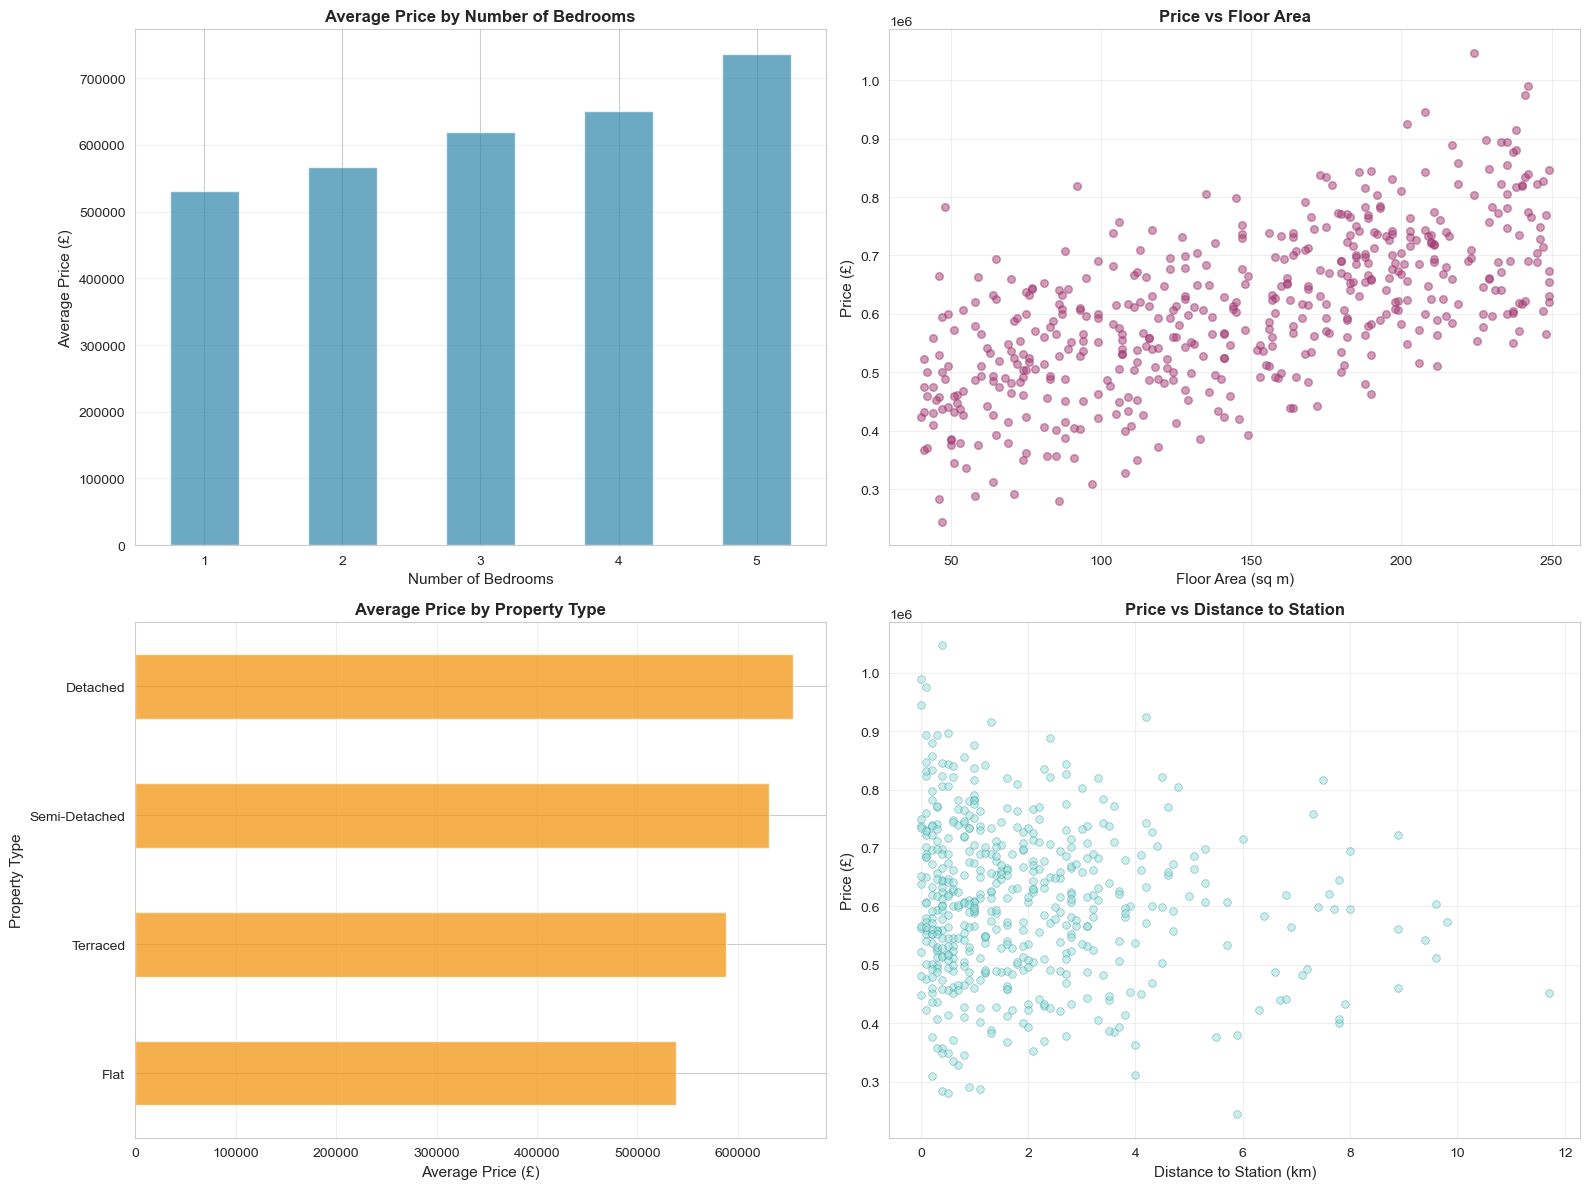


💡 Observations:
  • More bedrooms generally means higher prices
  • Larger floor area correlates with higher prices
  • Detached houses command premium prices
  • Properties closer to stations tend to be more expensive


In [39]:
# Visualize relationships between features and price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bedrooms vs Price
df.groupby('bedrooms')['price_gbp'].mean().plot(kind='bar', ax=axes[0, 0], color='#2E86AB', alpha=0.7)
axes[0, 0].set_xlabel('Number of Bedrooms', fontsize=11)
axes[0, 0].set_ylabel('Average Price (£)', fontsize=11)
axes[0, 0].set_title('Average Price by Number of Bedrooms', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Floor Area vs Price
axes[0, 1].scatter(df['floor_area_sqm'], df['price_gbp'], alpha=0.5, color='#A23B72', s=30)
axes[0, 1].set_xlabel('Floor Area (sq m)', fontsize=11)
axes[0, 1].set_ylabel('Price (£)', fontsize=11)
axes[0, 1].set_title('Price vs Floor Area', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Property Type vs Price
df.groupby('property_type')['price_gbp'].mean().sort_values().plot(kind='barh', 
                                                                     ax=axes[1, 0],
                                                                     color='#F18F01', alpha=0.7)
axes[1, 0].set_xlabel('Average Price (£)', fontsize=11)
axes[1, 0].set_ylabel('Property Type', fontsize=11)
axes[1, 0].set_title('Average Price by Property Type', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Distance to Station vs Price
axes[1, 1].scatter(df['distance_to_station_km'], df['price_gbp'], alpha=0.5, 
                   color='#95E1D3', s=30, edgecolor='#2E86AB', linewidth=0.5)
axes[1, 1].set_xlabel('Distance to Station (km)', fontsize=11)
axes[1, 1].set_ylabel('Price (£)', fontsize=11)
axes[1, 1].set_title('Price vs Distance to Station', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observations:")
print("  • More bedrooms generally means higher prices")
print("  • Larger floor area correlates with higher prices")
print("  • Detached houses command premium prices")
print("  • Properties closer to stations tend to be more expensive")

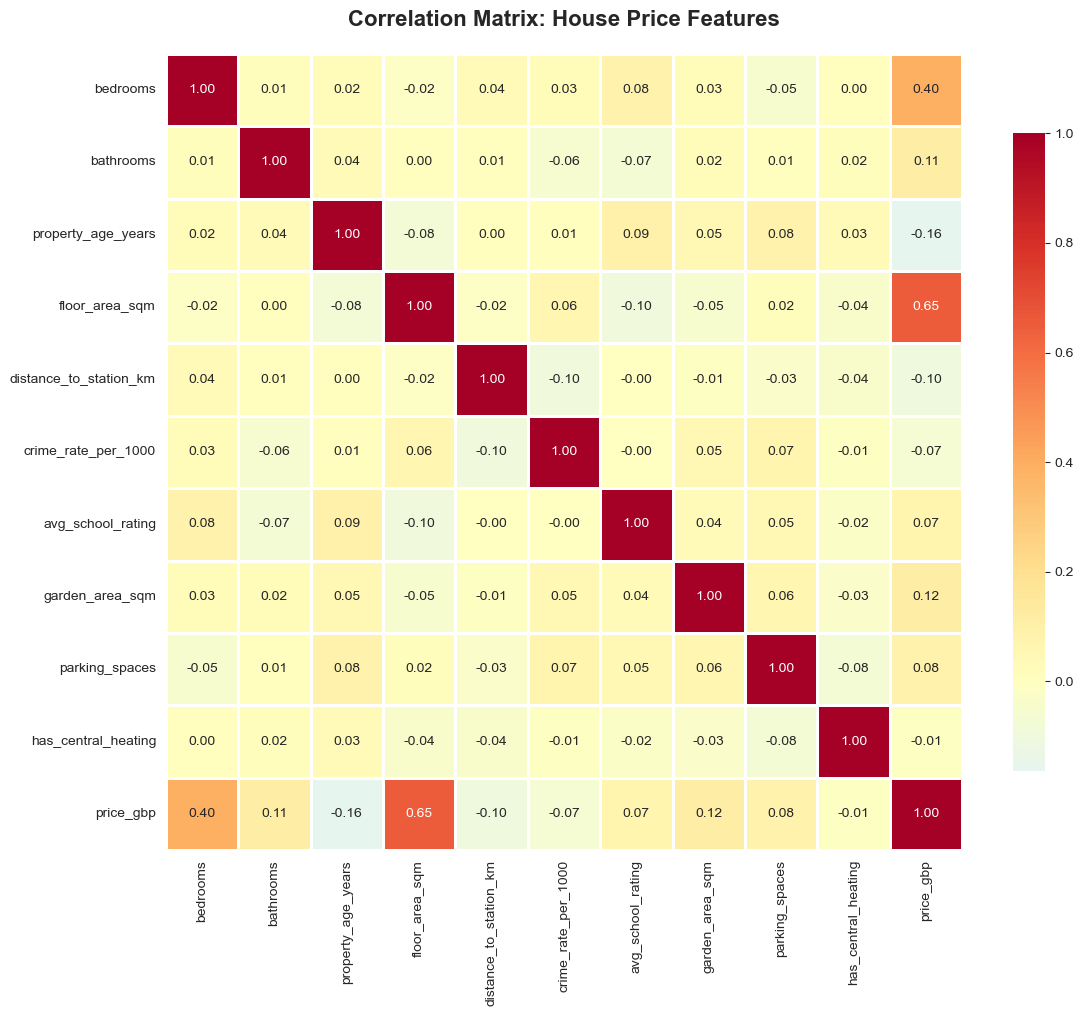


Top Correlations with Price:
floor_area_sqm            0.651000
bedrooms                  0.395625
garden_area_sqm           0.117198
bathrooms                 0.111531
parking_spaces            0.079595
avg_school_rating         0.068780
has_central_heating      -0.010385
crime_rate_per_1000      -0.066888
distance_to_station_km   -0.101856
property_age_years       -0.163425

💡 Strong positive correlations (price increases with):
  • floor_area_sqm: Larger houses cost more
  • bedrooms: More bedrooms = higher price
  • avg_school_rating: Better schools = higher prices

💡 Strong negative correlations (price decreases with):
  • crime_rate: Higher crime = lower prices
  • distance_to_station: Further from transport = lower prices


In [28]:
# Correlation heatmap
# Select numeric columns only
numeric_cols = ['bedrooms', 'bathrooms', 'property_age_years', 'floor_area_sqm',
                'distance_to_station_km', 'crime_rate_per_1000', 'avg_school_rating',
                'garden_area_sqm', 'parking_spaces', 'has_central_heating', 'price_gbp']

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: House Price Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nTop Correlations with Price:")
price_corr = correlation['price_gbp'].drop('price_gbp').sort_values(ascending=False)
print(price_corr.to_string())

print("\n💡 Strong positive correlations (price increases with):")
print("  • floor_area_sqm: Larger houses cost more")
print("  • bedrooms: More bedrooms = higher price")
print("  • avg_school_rating: Better schools = higher prices")
print("\n💡 Strong negative correlations (price decreases with):")
print("  • crime_rate: Higher crime = lower prices")
print("  • distance_to_station: Further from transport = lower prices")

### Step 2: Prepare Data for Machine Learning

In [40]:
# For simplicity, we'll use only numeric features for our first model
# (Later you can add categorical features with encoding)

# Select features (X) and target (y)
feature_columns = ['bedrooms', 'bathrooms', 'floor_area_sqm', 'distance_to_station_km',
                   'crime_rate_per_1000', 'avg_school_rating', 'garden_area_sqm', 
                   'parking_spaces', 'has_central_heating']

X = df[feature_columns]
y = df['price_gbp']

print("Features (X):")
X.head()

Features (X):


,bedrooms,bathrooms,floor_area_sqm,distance_to_station_km,crime_rate_per_1000,avg_school_rating,garden_area_sqm,parking_spaces,has_central_heating
0,2,2,68,0.6,1.5,9.8,94,1,1
1,5,2,224,0.4,12.2,5.9,134,1,1
2,3,1,78,2.4,14.1,7.4,67,1,1
3,3,2,223,1.9,3.8,6.4,146,1,1
4,2,2,210,2.0,2.5,7.9,127,1,1


In [41]:
print(f"\nShape: {X.shape}")

print("\n" + "="*70)
print("\nTarget (y):")
print(y.head())
print(f"\nShape: {y.shape}")


Shape: (500, 9)


Target (y):
0     490000.0
1    1047000.0
2     571000.0
3     696000.0
4     735000.0
Name: price_gbp, dtype: float64

Shape: (500,)


### Step 3: Split Data into Training and Testing Sets

In [42]:
# Split data: 80% training, 20% testing
(X_train, X_test, y_train, y_test) = train_test_split(X, y, test_size=0.2, random_state=42)


print("Data Split Complete!")
print("="*70)
print(f"Training set:   {X_train.shape[0]} properties ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Testing set:    {X_test.shape[0]} properties ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Total:          {len(df)} properties")

print("\n Why split the data?")
print("  • Training set: Used to teach the model")
print("  • Testing set: Used to evaluate how well the model performs on NEW, unseen data")
print("  • This prevents overfitting (memorizing training data instead of learning patterns)")

Data Split Complete!
Training set:   400 properties (80.0%)
Testing set:    100 properties (20.0%)
Total:          500 properties

 Why split the data?
  • Training set: Used to teach the model
  • Testing set: Used to evaluate how well the model performs on NEW, unseen data
  • This prevents overfitting (memorizing training data instead of learning patterns)


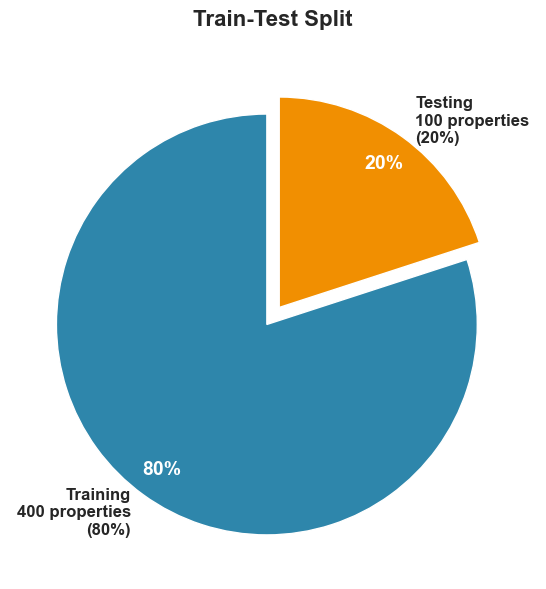

In [33]:
# Visualize the split
fig, ax = plt.subplots(figsize=(10, 6))

# Create pie chart
sizes = [len(X_train), len(X_test)]
labels = [f'Training\n{len(X_train)} properties\n(80%)', 
          f'Testing\n{len(X_test)} properties\n(20%)']
colors = ['#2E86AB', '#F18F01']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
                                    startangle=90, explode=explode,
                                    textprops={'fontsize': 12, 'weight': 'bold'},
                                    pctdistance=0.85)

# Make percentage text white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)

ax.set_title('Train-Test Split', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### Step 4: Train the Model (Linear Regression)

In [43]:
# Create and train the model
print("Training Linear Regression Model...")
print("="*70)

model = LinearRegression()
model.fit(X_train, y_train) # training

print("✓ Model trained successfully!")
print("\nModel Equation:")
print("Price = Intercept + (Coefficient₁ × Feature₁) + (Coefficient₂ × Feature₂) + ...")

print(f"\nIntercept: £{model.intercept_:,.2f}")
print("\nFeature Coefficients:")
print("-"*70)
for feature, coef in zip(feature_columns, model.coef_):
    print(f"  {feature:30s}: £{coef:>10,.2f}")

print("\n Interpretation:")
print("  • Positive coefficients: Feature increases price")
print("  • Negative coefficients: Feature decreases price")
print(f"  • Each additional bedroom adds approximately £{model.coef_[0]:,.0f} to the price")
print(f"  • Each km further from station decreases price by £{abs(model.coef_[3]):,.0f}")

Training Linear Regression Model...
✓ Model trained successfully!

Model Equation:
Price = Intercept + (Coefficient₁ × Feature₁) + (Coefficient₂ × Feature₂) + ...

Intercept: £139,561.46

Feature Coefficients:
----------------------------------------------------------------------
  bedrooms                      : £ 47,218.86
  bathrooms                     : £ 23,479.26
  floor_area_sqm                : £  1,485.84
  distance_to_station_km        : £ -8,327.74
  crime_rate_per_1000           : £ -2,648.34
  avg_school_rating             : £  8,783.86
  garden_area_sqm               : £    462.42
  parking_spaces                : £ 17,215.26
  has_central_heating           : £ 14,716.58

 Interpretation:
  • Positive coefficients: Feature increases price
  • Negative coefficients: Feature decreases price
  • Each additional bedroom adds approximately £47,219 to the price
  • Each km further from station decreases price by £8,328


### Step 5: Make Predictions

In [44]:
# Make predictions on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions Made!")
print("="*70)

# Show some example predictions
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_test_pred[:10],
    'Difference': y_test.values[:10] - y_test_pred[:10]
})
comparison['Actual Price'] = comparison['Actual Price'].apply(lambda x: f'£{x:,.0f}')
comparison['Predicted Price'] = comparison['Predicted Price'].apply(lambda x: f'£{x:,.0f}')
comparison['Difference'] = comparison['Difference'].apply(lambda x: f'£{x:,.0f}')

print("\nFirst 10 Test Set Predictions:")
print(comparison.to_string(index=False))

print("\n💡 The model predicts prices based on learned patterns from training data!")

Predictions Made!

First 10 Test Set Predictions:
Actual Price Predicted Price Difference
    £546,000        £597,568   £-51,568
    £775,000        £827,937   £-52,937
    £336,000        £416,193   £-80,193
    £532,000        £470,452    £61,548
    £503,000        £537,160   £-34,160
    £620,000        £697,484   £-77,484
    £513,000        £619,305  £-106,305
    £586,000        £568,385    £17,615
    £740,000        £634,176   £105,824
    £633,000        £571,576    £61,424

💡 The model predicts prices based on learned patterns from training data!


### Step 6: Evaluate Model Performance

Now we measure how well our model performs using several metrics:

In [36]:
# Calculate performance metrics
# Training set performance
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test set performance
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("MODEL PERFORMANCE METRICS")
print("="*70)
print("\n TRAINING SET PERFORMANCE:")
print(f"  • R² Score:  {train_r2:.4f}")
print(f"  • RMSE:      £{train_rmse:,.2f}")
print(f"  • MAE:       £{train_mae:,.2f}")

print("\n TEST SET PERFORMANCE (Most Important!):")
print(f"  • R² Score:  {test_r2:.4f}")
print(f"  • RMSE:      £{test_rmse:,.2f}")
print(f"  • MAE:       £{test_mae:,.2f}")

print("\n" + "="*70)

MODEL PERFORMANCE METRICS

 TRAINING SET PERFORMANCE:
  • R² Score:  0.6656
  • RMSE:      £77,736.61
  • MAE:       £61,667.29

 TEST SET PERFORMANCE (Most Important!):
  • R² Score:  0.6453
  • RMSE:      £75,647.45
  • MAE:       £59,727.34



### Understanding Performance Metrics

Let's explain what each metric means:

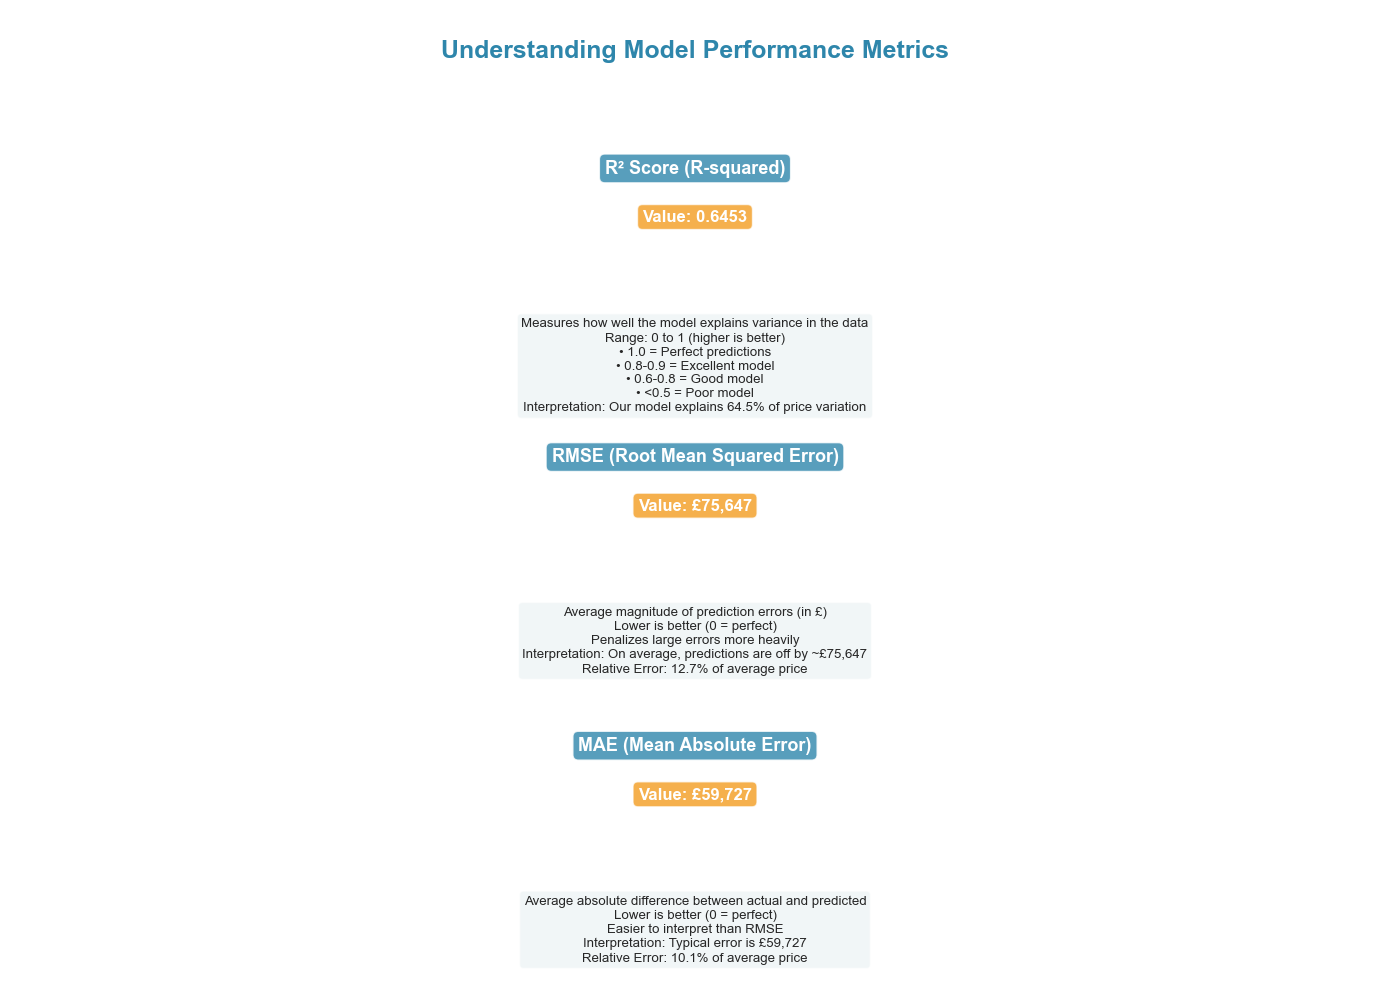

In [20]:
# Visual explanation of metrics
fig, ax = plt.subplots(figsize=(14, 10))

ax.text(0.5, 0.95, 'Understanding Model Performance Metrics', ha='center', 
        fontsize=18, fontweight='bold', color='#2E86AB')

metrics_info = [
    (
        'R² Score (R-squared)',
        f'Value: {test_r2:.4f}',
        'Measures how well the model explains variance in the data\n' +
        'Range: 0 to 1 (higher is better)\n' +
        '• 1.0 = Perfect predictions\n' +
        '• 0.8-0.9 = Excellent model\n' +
        '• 0.6-0.8 = Good model\n' +
        '• <0.5 = Poor model\n' +
        f'Interpretation: Our model explains {test_r2*100:.1f}% of price variation',
        0.78
    ),
    (
        'RMSE (Root Mean Squared Error)',
        f'Value: £{test_rmse:,.0f}',
        'Average magnitude of prediction errors (in £)\n' +
        'Lower is better (0 = perfect)\n' +
        'Penalizes large errors more heavily\n' +
        f'Interpretation: On average, predictions are off by ~£{test_rmse:,.0f}\n' +
        f'Relative Error: {test_rmse/y_test.mean()*100:.1f}% of average price',
        0.48
    ),
    (
        'MAE (Mean Absolute Error)',
        f'Value: £{test_mae:,.0f}',
        'Average absolute difference between actual and predicted\n' +
        'Lower is better (0 = perfect)\n' +
        'Easier to interpret than RMSE\n' +
        f'Interpretation: Typical error is £{test_mae:,.0f}\n' +
        f'Relative Error: {test_mae/y_test.mean()*100:.1f}% of average price',
        0.18
    )
]

for metric_name, value, explanation, y_pos in metrics_info:
    # Metric name
    ax.text(0.5, y_pos + 0.05, metric_name, ha='center', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#2E86AB', alpha=0.8),
            color='white')
    
    # Value
    ax.text(0.5, y_pos, value, ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.7),
            color='white')
    
    # Explanation
    ax.text(0.5, y_pos - 0.1, explanation, ha='center', va='top', fontsize=9.5,
            bbox=dict(boxstyle='round', facecolor='#E8F1F2', alpha=0.6))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### Visualizing Model Performance

#### 1. Predicted vs Actual Prices (Line of Best Fit)

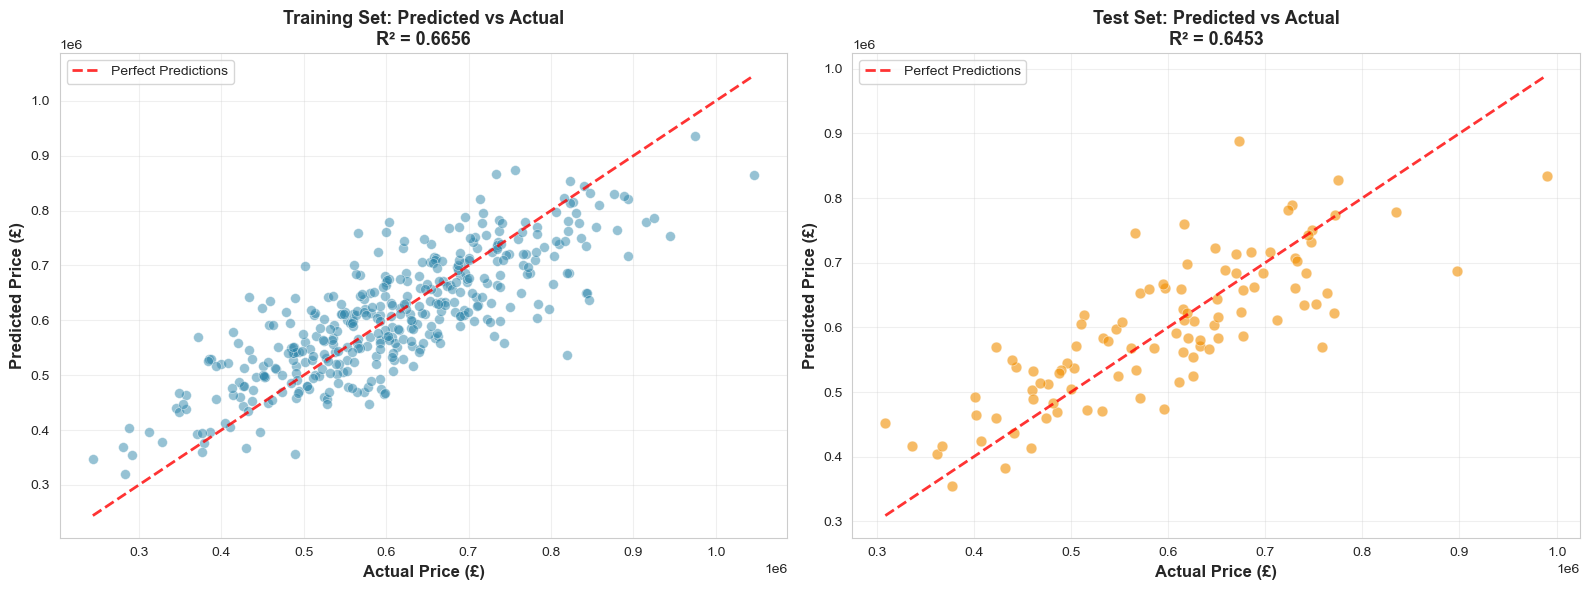


 Interpretation:
  • Points close to red line = accurate predictions
  • Points far from red line = large prediction errors
  • Test set performance is what matters most!


In [37]:
# Create predicted vs actual plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=50, color='#2E86AB', edgecolor='white', linewidth=0.5)

# Perfect prediction line (diagonal)
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
             label='Perfect Predictions', alpha=0.8)

axes[0].set_xlabel('Actual Price (£)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Price (£)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Training Set: Predicted vs Actual\nR² = {train_r2:.4f}', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=60, color='#F18F01', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
             label='Perfect Predictions', alpha=0.8)

axes[1].set_xlabel('Actual Price (£)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Price (£)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Test Set: Predicted vs Actual\nR² = {test_r2:.4f}', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("  • Points close to red line = accurate predictions")
print("  • Points far from red line = large prediction errors")
print("  • Test set performance is what matters most!")

#### 2. Feature Importance (Coefficient Analysis)

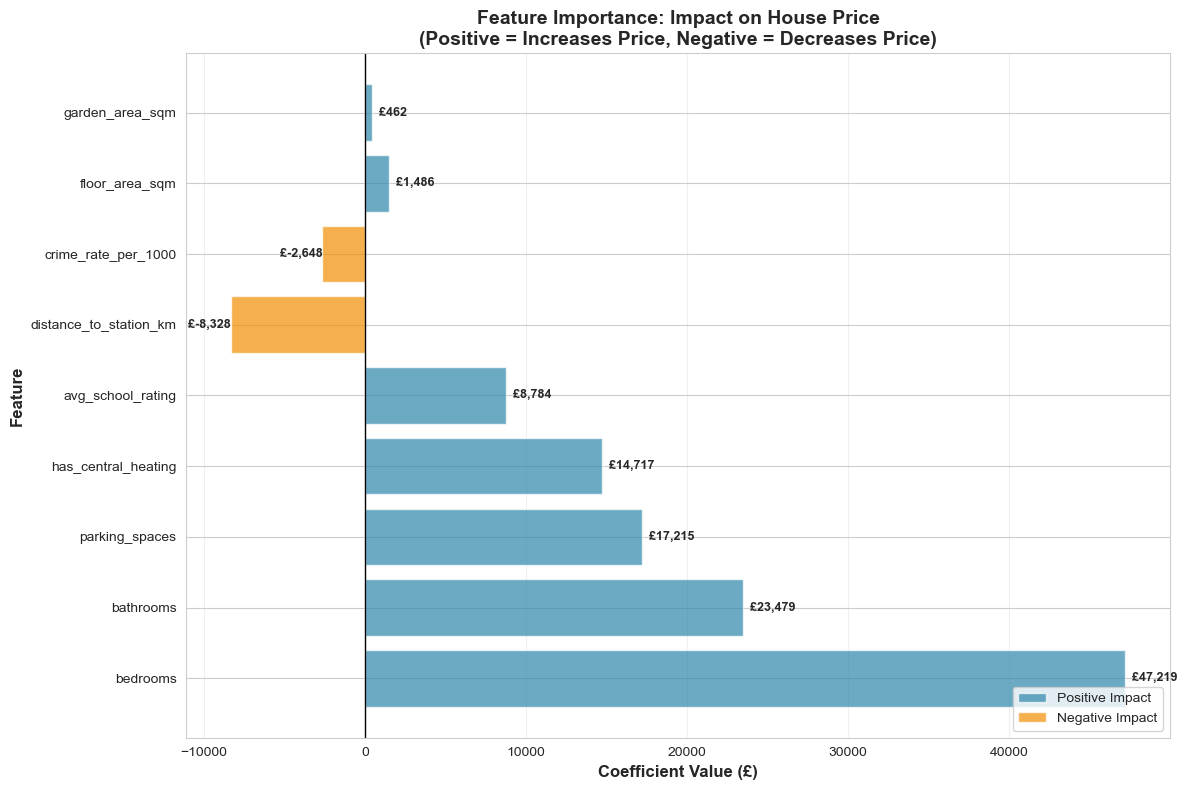


💡 Feature Impact Interpretation:

Top 3 Positive Features (increase price):
  • bedrooms: +£47,219 per unit
  • bathrooms: +£23,479 per unit
  • parking_spaces: +£17,215 per unit

Top 3 Negative Features (decrease price):
  • distance_to_station_km: £-8,328 per unit
  • crime_rate_per_1000: £-2,648 per unit


In [39]:
# Visualize feature coefficients
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2E86AB' if x > 0 else '#F18F01' for x in coefficients['Coefficient']]
bars = ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7)

ax.axvline(0, color='black', linewidth=1, linestyle='-')
ax.set_xlabel('Coefficient Value (£)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: Impact on House Price\n(Positive = Increases Price, Negative = Decreases Price)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(coefficients.iterrows()):
    value = row['Coefficient']
    ax.text(value, i, f'  £{value:,.0f}', va='center', 
            ha='left' if value > 0 else 'right',
            fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E86AB', alpha=0.7, label='Positive Impact'),
                  Patch(facecolor='#F18F01', alpha=0.7, label='Negative Impact')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Feature Impact Interpretation:")
print("\nTop 3 Positive Features (increase price):")
for i, row in coefficients.head(3).iterrows():
    if row['Coefficient'] > 0:
        print(f"  • {row['Feature']}: +£{row['Coefficient']:,.0f} per unit")

print("\nTop 3 Negative Features (decrease price):")
negative = coefficients[coefficients['Coefficient'] < 0].head(3)
for i, row in negative.iterrows():
    print(f"  • {row['Feature']}: £{row['Coefficient']:,.0f} per unit")

### Model Performance Summary

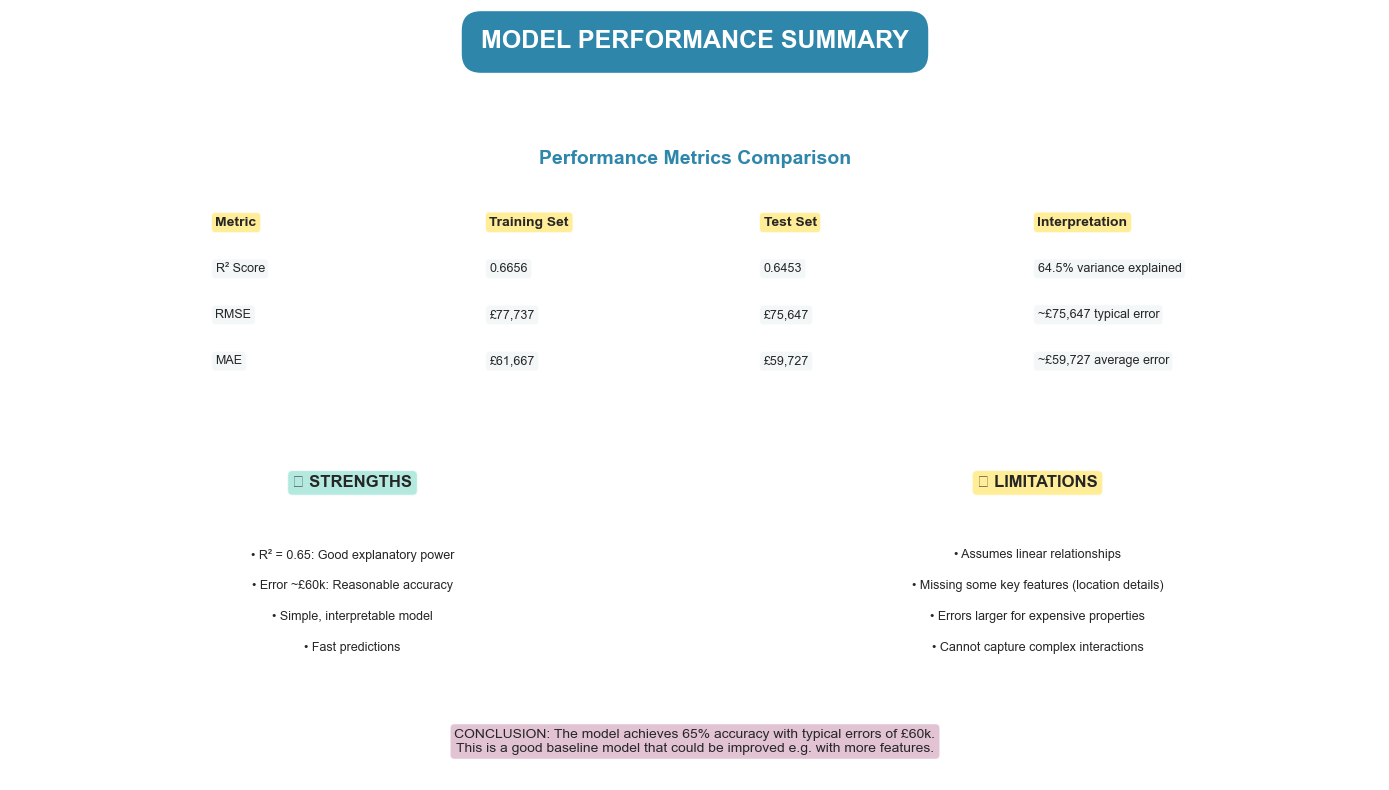

In [41]:
# Create a performance summary
fig, ax = plt.subplots(figsize=(14, 8))

ax.text(0.5, 0.95, 'MODEL PERFORMANCE SUMMARY', ha='center', fontsize=18, 
        fontweight='bold', color='white',
        bbox=dict(boxstyle='round', facecolor='#2E86AB', pad=0.8))

# Performance metrics comparison
y_pos = 0.80
ax.text(0.5, y_pos, 'Performance Metrics Comparison', ha='center', fontsize=14, 
        fontweight='bold', color='#2E86AB')

y_pos = 0.72
metrics_data = [
    ['Metric', 'Training Set', 'Test Set', 'Interpretation'],
    ['R² Score', f'{train_r2:.4f}', f'{test_r2:.4f}', f'{test_r2*100:.1f}% variance explained'],
    ['RMSE', f'£{train_rmse:,.0f}', f'£{test_rmse:,.0f}', f'~£{test_rmse:,.0f} typical error'],
    ['MAE', f'£{train_mae:,.0f}', f'£{test_mae:,.0f}', f'~£{test_mae:,.0f} average error']
]

col_widths = [0.2, 0.22, 0.22, 0.36]
col_positions = [0.15, 0.35, 0.55, 0.75]

for i, row in enumerate(metrics_data):
    y = y_pos - (i * 0.06)
    for col_val, x_pos in zip(row, col_positions):
        if i == 0:  # Header
            ax.text(x_pos, y, col_val, ha='left', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='#FFE66D', alpha=0.7))
        else:
            ax.text(x_pos, y, col_val, ha='left', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='#E8F1F2', alpha=0.5))

# Model strengths and limitations
y_pos = 0.38
ax.text(0.25, y_pos, '✓ STRENGTHS', ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#95E1D3', alpha=0.7))
ax.text(0.75, y_pos, '⚠ LIMITATIONS', ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFE66D', alpha=0.7))

strengths = [
    f'• R² = {test_r2:.2f}: Good explanatory power',
    f'• Error ~£{test_mae/1000:.0f}k: Reasonable accuracy',
    '• Simple, interpretable model',
    '• Fast predictions'
]

limitations = [
    '• Assumes linear relationships',
    '• Missing some key features (location details)',
    '• Errors larger for expensive properties',
    '• Cannot capture complex interactions'
]

y = 0.30
for strength in strengths:
    ax.text(0.25, y, strength, ha='center', fontsize=9, va='top')
    y -= 0.04

y = 0.30
for limitation in limitations:
    ax.text(0.75, y, limitation, ha='center', fontsize=9, va='top')
    y -= 0.04

# Conclusion
ax.text(0.5, 0.05, 
        f'CONCLUSION: The model achieves {test_r2*100:.0f}% accuracy with typical errors of £{test_mae/1000:.0f}k.\n' +
        'This is a good baseline model that could be improved e.g. with more features.',
        ha='center', fontsize=10, va='center',
        bbox=dict(boxstyle='round', facecolor='#A23B72', alpha=0.3))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### Making Predictions on New Properties

In [49]:
# Example: Predict price for a new property
new_property = pd.DataFrame({
    'bedrooms': [3],
    'bathrooms': [2],
    'floor_area_sqm': [120],
    'distance_to_station_km': [1.5],
    'crime_rate_per_1000': [8.0],
    'avg_school_rating': [8.5],
    'garden_area_sqm': [50],
    'parking_spaces': [2],
    'has_central_heating': [1]
})

predicted_price = model.predict(new_property)[0]

print("\n🏠 PROPERTY VALUATION")
print("="*70)
print("\nProperty Details:")
for col in new_property.columns:
    print(f"  • {col:30s}: {new_property[col].values[0]}")

print(f"\n💰 PREDICTED PRICE: £{predicted_price:,.0f}")
print("="*70)

# Confidence interval (approximate)
lower_bound = predicted_price - 2 * test_mae
upper_bound = predicted_price + 2 * test_mae

print(f"\n95% Confidence Interval:")
print(f"  Lower bound: £{lower_bound:,.0f}")
print(f"  Upper bound: £{upper_bound:,.0f}")
print(f"\n💡 The actual price is likely between £{lower_bound:,.0f} and £{upper_bound:,.0f}")


🏠 PROPERTY VALUATION

Property Details:
  • bedrooms                      : 3
  • bathrooms                     : 2
  • floor_area_sqm                : 120
  • distance_to_station_km        : 1.5
  • crime_rate_per_1000           : 8.0
  • avg_school_rating             : 8.5
  • garden_area_sqm               : 50
  • parking_spaces                : 2
  • has_central_heating           : 1

💰 PREDICTED PRICE: £619,730

95% Confidence Interval:
  Lower bound: £500,275
  Upper bound: £739,184

💡 The actual price is likely between £500,275 and £739,184


---

<a id='summary'></a>
## 6. Summary

### What We've Learned

🎯 **Machine Learning Concepts:**
- Machine learning teaches computers to learn from data
- Three main categories: Supervised, Unsupervised, Reinforcement
- Supervised learning uses labeled data to make predictions
- Regression predicts numbers; Classification predicts categories

🎯 **The ML Workflow:**
1. Collect and prepare data
2. Split into training and testing sets
3. Choose and train a model
4. Evaluate performance
5. Make predictions on new data

🎯 **Key Terminology:**
- **Features (X)**: Input variables used for prediction
- **Target (y)**: Output variable we want to predict
- **Training data**: Used to teach the model
- **Testing data**: Used to evaluate the model
- **Model**: Mathematical representation of learned patterns

🎯 **Performance Metrics:**
- **R² Score**: Measures how well model explains variance (higher is better)
- **RMSE**: Average magnitude of errors (lower is better)
- **MAE**: Average absolute error (lower is better)
- **Residuals**: Difference between actual and predicted values
